# **FINAL ÇALIŞMASI**

Bu bölümde, vize aşamasında geliştirilen lineer modellerin üzerine
PyTorch kullanılarak derin öğrenme tabanlı ileri seviye modeller geliştirilmiştir.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Bu hücrede, final çalışması için PyTorch ortamını hazırlar ve
GPU/CPU seçimini yaparak derin öğrenme modellerinin çalışacağı cihazı belirler

In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


**Data Load**

Bu hücrede, Drive’daki temizlenmiş veri setini (train_clean_final.csv) okur ve hedef değişkeni (target) ile feature’ları ayırır.
Ayrıca veri boyutunu ve hedef kolonun doğru bulunup bulunmadığını kontrol ederek bir sonraki adım için doğrulama yapar.


In [4]:
import os
import numpy as np
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/veri_proje"
DATA_FILE = os.path.join(DATA_DIR, "train_clean_final.csv")

df = pd.read_csv(DATA_FILE)

print("Shape:", df.shape)


n = len(df.columns)
if n <= 25:
    print("Columns:", df.columns.tolist())
else:
    print("Columns (first 25):", df.columns[:25].tolist())
    print("Total columns:", n)

possible_targets = ["trip_duration_log", "y", "log_trip_duration", "trip_duration"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

print("Target column found:", target_col)

# Hedefi ayır
y = df[target_col].values.astype(np.float32)
X = df.drop(columns=[target_col])

print("X shape:", X.shape, "y shape:", y.shape)
print(
    "y min/mean/max:",
    float(np.min(y)),
    float(np.mean(y)),
    float(np.max(y))
)


Shape: (1447628, 16)
Columns: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'hour', 'weekday', 'month', 'is_weekend', 'haversine_km']
Target column found: trip_duration
X shape: (1447628, 15) y shape: (1447628,)
y min/mean/max: 60.0 840.8936767578125 7191.0


**Split + Feature Types + Scaling**

Bu hücrede , veriyi train/val/test olarak ayırır ve sayısal/kategorik kolonları otomatik tespit eder.
Sayısal kolonları StandardScaler ile ölçekleyerek PyTorch modellerinin daha stabil öğrenmesini sağlar.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 80/20 split (train+val / test)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# train/val split (train / val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.20, random_state=42
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Kolon tipleri (object -> kategorik kabul)
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numerical cols count:", len(num_cols))

# Sayısalları ölçekle
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_val_num   = scaler.transform(X_val[num_cols])
X_test_num  = scaler.transform(X_test[num_cols])

print("Scaled num shapes:", X_train_num.shape, X_val_num.shape, X_test_num.shape)

Train: (926481, 15) Val: (231621, 15) Test: (289526, 15)
Categorical cols: ['id', 'pickup_datetime', 'dropoff_datetime', 'store_and_fwd_flag']
Numerical cols count: 11
Scaled num shapes: (926481, 11) (231621, 11) (289526, 11)


**Datetime Feature Engineering**

Bu blok, pickup ve dropoff datetime kolonlarından saat, gün, ay gibi sayısal özellikler çıkarır.
Böylece zaman bilgisini derin öğrenme modellerinin öğrenebileceği forma dönüştürmüş oluruz.

In [ ]:
# Datetime kolonları datetime tipine çevir
import pandas as pd
for col in ["pickup_datetime", "dropoff_datetime"]:
    X_train[col] = pd.to_datetime(X_train[col])
    X_val[col]   = pd.to_datetime(X_val[col])
    X_test[col]  = pd.to_datetime(X_test[col])

def extract_datetime_features(df):
    df = df.copy()
    df["pickup_hour"] = df["pickup_datetime"].dt.hour
    df["pickup_day"]  = df["pickup_datetime"].dt.dayofweek
    df["pickup_month"] = df["pickup_datetime"].dt.month

    df["dropoff_hour"] = df["dropoff_datetime"].dt.hour
    df["dropoff_day"]  = df["dropoff_datetime"].dt.dayofweek
    df["dropoff_month"] = df["dropoff_datetime"].dt.month

    return df.drop(columns=["pickup_datetime", "dropoff_datetime"])

# Yeni feature’ları çıkar
X_train_fe = extract_datetime_features(X_train)
X_val_fe   = extract_datetime_features(X_val)
X_test_fe  = extract_datetime_features(X_test)

print("After datetime FE shapes:")
print(X_train_fe.shape, X_val_fe.shape, X_test_fe.shape)
print("Columns after FE:", X_train_fe.columns.tolist())

After datetime FE shapes:
(926481, 19) (231621, 19) (289526, 19)
Columns after FE: ['id', 'vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'hour', 'weekday', 'month', 'is_weekend', 'haversine_km', 'pickup_hour', 'pickup_day', 'pickup_month', 'dropoff_hour', 'dropoff_day', 'dropoff_month']


**Encoding (fixed: drop id)**

bu hücrede, RAM sorununa neden olan 'id' kolonunu modelden çıkarır (kimlik bilgisidir, tahmin gücü yoktur).
Kalan kategorik kolon(lar) için One-Hot Encoding uygular ve PyTorch’a hazır X_train_all/X_val_all/X_test_all matrislerini üretir

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1) id kolonunu çıkar
X_train_fe2 = X_train_fe.drop(columns=["id"])
X_val_fe2   = X_val_fe.drop(columns=["id"])
X_test_fe2  = X_test_fe.drop(columns=["id"])

# 2) kategorik/sayısal kolonları belirle
cat_cols_fe = X_train_fe2.select_dtypes(include=["object"]).columns.tolist()
num_cols_fe = [c for c in X_train_fe2.columns if c not in cat_cols_fe]

print("Categorical cols (FE):", cat_cols_fe)
print("Numerical cols (FE) count:", len(num_cols_fe))
print("Total cols after drop id:", X_train_fe2.shape[1])

# 3) One-Hot + passthrough
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_fe),
        ("num", "passthrough", num_cols_fe),
    ]
)

X_train_all = preprocessor.fit_transform(X_train_fe2)
X_val_all   = preprocessor.transform(X_val_fe2)
X_test_all  = preprocessor.transform(X_test_fe2)

# 4) float32
X_train_all = X_train_all.astype(np.float32)
X_val_all   = X_val_all.astype(np.float32)
X_test_all  = X_test_all.astype(np.float32)

print("Final matrices shapes:")
print("X_train_all:", X_train_all.shape)
print("X_val_all  :", X_val_all.shape)
print("X_test_all :", X_test_all.shape)

Categorical cols (FE): ['store_and_fwd_flag']
Numerical cols (FE) count: 17
Total cols after drop id: 18
Final matrices shapes:
X_train_all: (926481, 19)
X_val_all  : (231621, 19)
X_test_all : (289526, 19)


**PyTorch Dataset & DataLoader**

Bu hücrede, numpy matrislerini PyTorch Dataset formatına çevirir ve mini-batch eğitim için DataLoader oluşturur.
Böylece modelleri batch halinde eğitip doğrulama/test aşamalarını standart bir akışla yapabiliriz.




In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 2048

train_ds = TabularDataset(X_train_all, y_train)
val_ds   = TabularDataset(X_val_all, y_val)
test_ds  = TabularDataset(X_test_all, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape, "Batch y:", yb.shape)
print("X dtype:", xb.dtype, "y dtype:", yb.dtype)

Batch X: torch.Size([2048, 19]) Batch y: torch.Size([2048, 1])
X dtype: torch.float32 y dtype: torch.float32


**Tabular MLP (Model + Train/Eval Loop)**

Bu hücrede, tabular veriler için basit bir MLP regresyon modeli tanımlar ve eğitim/doğrulama döngüsünü çalıştırır.
Eğitim sonunda RMSE, MAE ve R² metriklerini validation seti üzerinde hesaplayarak baseline DL performansını elde eder

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Model
class TabularMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Helpers
def rmse(y_true, y_pred):
    return float(torch.sqrt(torch.mean((y_true - y_pred) ** 2)).cpu().item())

def mae(y_true, y_pred):
    return float(torch.mean(torch.abs(y_true - y_pred)).cpu().item())

def r2_torch(y_true, y_pred):
    # R² = 1 - SS_res/SS_tot
    y_true = y_true.detach()
    y_pred = y_pred.detach()
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return float((1 - ss_res / (ss_tot + 1e-12)).cpu().item())

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    ys, preds = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        out = model(xb)
        ys.append(yb)
        preds.append(out)
    y_true = torch.cat(ys, dim=0)
    y_pred = torch.cat(preds, dim=0)
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "R2": r2_torch(y_true, y_pred),
    }

# Train
input_dim = X_train_all.shape[1]
model = TabularMLP(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 5
for epoch in range(1, epochs + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_metrics = evaluate(model, val_loader)
    print(f"Epoch {epoch}/{epochs} | TrainLoss: {total_loss/len(train_loader):.6f} | "
          f"Val RMSE: {val_metrics['RMSE']:.4f} | Val MAE: {val_metrics['MAE']:.4f} | Val R2: {val_metrics['R2']:.4f}")

Epoch 1/5 | TrainLoss: 433221.645247 | Val RMSE: 476.7034 | Val MAE: 335.3286 | Val R2: 0.4780
Epoch 2/5 | TrainLoss: 189266.475304 | Val RMSE: 404.6303 | Val MAE: 258.6178 | Val R2: 0.6239
Epoch 3/5 | TrainLoss: 171204.745154 | Val RMSE: 396.4268 | Val MAE: 247.6442 | Val R2: 0.6390
Epoch 4/5 | TrainLoss: 164516.712300 | Val RMSE: 387.6934 | Val MAE: 245.8825 | Val R2: 0.6547
Epoch 5/5 | TrainLoss: 163172.320261 | Val RMSE: 384.7177 | Val MAE: 244.5388 | Val R2: 0.6600


**Test Evaluation (Tabular MLP)**

Bu hücrede, eğitilmiş Tabular MLP modelini test seti üzerinde değerlendirir ve RMSE/MAE/R² metriklerini raporlar.
Ayrıca sonuçları daha sonra final karşılaştırma tablosuna koymak için bir sözlük (results) içinde saklar

In [ ]:
tabmlp_test = evaluate(model, test_loader)
print("Tabular MLP TEST metrics:", tabmlp_test)

results = {}
results["Tabular_MLP"] = tabmlp_test
results

Tabular MLP TEST metrics: {'RMSE': 376.4405822753906, 'MAE': 242.8837432861328, 'R2': 0.665520191192627}


{'Tabular_MLP': {'RMSE': 376.4405822753906,
  'MAE': 242.8837432861328,
  'R2': 0.665520191192627}}

**ResNet-style MLP (Advanced Model)**

Bu hücrede, skip connection (residual) kullanan gelişmiş bir MLP modeli tanımlar ve Tabular MLP ile aynı eğitim akışıyla eğitir.
Amaç, aynı veri ve metrikler altında residual mimarinin performansa etkisini objektif olarak karşılaştırmaktır.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dim, dim)

    def forward(self, x):
        out = self.fc1(x)
        out = self.act(out)
        out = self.drop(out)
        out = self.fc2(out)
        return self.act(x + out)  # residual + activation

class ResNetMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_blocks=2, dropout=0.2):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_dim, dropout) for _ in range(num_blocks)])
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.out(x)

# Model kur
input_dim = X_train_all.shape[1]
resnet_model = ResNetMLP(input_dim=input_dim, hidden_dim=128, num_blocks=2, dropout=0.2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(resnet_model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 5
for epoch in range(1, epochs + 1):
    resnet_model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = resnet_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    val_metrics = evaluate(resnet_model, val_loader)
    print(f"[ResNetMLP] Epoch {epoch}/{epochs} | TrainLoss: {total_loss/len(train_loader):.6f} | "
          f"Val RMSE: {val_metrics['RMSE']:.4f} | Val MAE: {val_metrics['MAE']:.4f} | Val R2: {val_metrics['R2']:.4f}")

[ResNetMLP] Epoch 1/5 | TrainLoss: 281042.942398 | Val RMSE: 388.3525 | Val MAE: 253.7702 | Val R2: 0.6536
[ResNetMLP] Epoch 2/5 | TrainLoss: 146141.877966 | Val RMSE: 365.9014 | Val MAE: 245.6515 | Val R2: 0.6925
[ResNetMLP] Epoch 3/5 | TrainLoss: 136618.030095 | Val RMSE: 360.7280 | Val MAE: 248.0316 | Val R2: 0.7011
[ResNetMLP] Epoch 4/5 | TrainLoss: 130758.810051 | Val RMSE: 352.9460 | Val MAE: 229.0209 | Val R2: 0.7139
[ResNetMLP] Epoch 5/5 | TrainLoss: 127433.216474 | Val RMSE: 350.0659 | Val MAE: 239.3982 | Val R2: 0.7185


**Test Evaluation (ResNetMLP)**

Bu hücrede, eğitilmiş ResNet-style MLP modelini test seti üzerinde değerlendirir ve RMSE/MAE/R² metriklerini raporlar.
Sonuçları results sözlüğüne ekleyerek Tabular MLP ile nihai karşılaştırmayı hazırlar.

In [ ]:
from pprint import PrettyPrinter

pp = PrettyPrinter(width=80, sort_dicts=False)

resnet_test = evaluate(resnet_model, test_loader)
print("ResNetMLP TEST metrics:")
pp.pprint(resnet_test)

results["ResNet_MLP"] = resnet_test
print("\nResults:")
pp.pprint(results)


ResNetMLP TEST metrics:
{'RMSE': 346.2058410644531, 'MAE': 238.22340393066406, 'R2': 0.7170915603637695}

Results:
{'Tabular_MLP': {'RMSE': 376.4405822753906,
                 'MAE': 242.8837432861328,
                 'R2': 0.665520191192627},
 'ResNet_MLP': {'RMSE': 346.2058410644531,
                'MAE': 238.22340393066406,
                'R2': 0.7170915603637695}}


**Final Comparison (RMSE/MAE/R2 + MAPE)**

Bu hücrede, iki modelin test performansını RMSE/MAE/R² ve MAPE ile karşılaştırır ve her metrik için en iyi modeli belirtir.
Çıktı olarak tek bir final tablo ve "best by metric" özetini verir.

In [ ]:
import torch
import pandas as pd

def mape_torch(y_true, y_pred, eps=1e-6):
    denom = torch.clamp(torch.abs(y_true), min=eps)
    return float((torch.mean(torch.abs((y_true - y_pred) / denom)) * 100).cpu().item())

@torch.no_grad()
def evaluate_full(model_, loader):
    model_.eval()
    ys, preds = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        out = model_(xb)
        ys.append(yb)
        preds.append(out)
    y_true = torch.cat(ys, dim=0)
    y_pred = torch.cat(preds, dim=0)
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "R2": r2_torch(y_true, y_pred),
        "MAPE": mape_torch(y_true, y_pred),
    }

# Test metriklerini hesapla
results_full = {
    "Tabular_MLP": evaluate_full(model, test_loader),
    "ResNet_MLP": evaluate_full(resnet_model, test_loader),
}

# Tablo oluştur
df_res = pd.DataFrame(results_full).T[["RMSE", "MAE", "R2", "MAPE"]].copy()
df_show = df_res.round({"RMSE": 3, "MAE": 3, "R2": 4, "MAPE": 2})

# En iyi modeller
best_rmse = df_res["RMSE"].idxmin()
best_mae  = df_res["MAE"].idxmin()
best_r2   = df_res["R2"].idxmax()
best_mape = df_res["MAPE"].idxmin()

print("=== FINAL MODEL COMPARISON (TEST) ===")
display(df_show)

print("\nBest by metric:")
print(f"- Best RMSE : {best_rmse}")
print(f"- Best MAE  : {best_mae}")
print(f"- Best R2   : {best_r2}")
print(f"- Best MAPE : {best_mape}")

=== FINAL MODEL COMPARISON (TEST) ===


,RMSE,MAE,R2,MAPE
Tabular_MLP,376.441,242.884,0.6655,38.42
ResNet_MLP,346.206,238.223,0.7171,40.55



Best by metric:
- Best RMSE : ResNet_MLP
- Best MAE  : ResNet_MLP
- Best R2   : ResNet_MLP
- Best MAPE : Tabular_MLP


# **VİZE ÇALIŞMASI**

In [ ]:
# Google Drive'ı bağlıyoruz ve proje klasörüne geçiyoruz.

from google.colab import drive
drive.mount('/content/drive')

%cd "/content/drive/MyDrive/veri_proje"

!pwd
!ls


Mounted at /content/drive
/content/drive/MyDrive/veri_proje
/content/drive/MyDrive/veri_proje
train_clean_final.csv  train.csv  Veri_kodum


KÜTÜPHANELER
Bu hücrede veri işleme (pandas, numpy), görselleştirme (matplotlib, seaborn) ve modelleme (sklearn) için gerekli tüm kütüphaneler içe aktarılır. Ayrıca çıktı görüntüleme ayarı yapılır ve sabit bir RANDOM_STATE tanımlanır.

In [ ]:
# modelleme için gerekli kütüphaneleri yüklüyoruz.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option("display.max_columns", 120)

RANDOM_STATE = 42


VERİ SETİNİ OKUMA
Temizlenmiş veri seti “train_clean_final.csv” dosyasından okunur. Veri boyutu ve ilk birkaç satır ekrana yazdırılır.

In [ ]:
# temiz veri setini okuyoruz.

df = pd.read_csv("train_clean_final.csv")

print("Veri boyutu:", df.shape)
df.head()


Veri boyutu: (1447628, 16)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,weekday,month,is_weekend,haversine_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,1,1.188588


VERİ SETİNİ İNCELEME
df.head(), df.info(), df.describe() ile veri yapısı, sütun tipleri, eksik veri durumu ve temel istatistikler incelenir.

In [ ]:
# İlk satırlar, info() ve describe() ile veri yapısını inceliyoruz.

display(df.head())
print("\nINFO:\n")
df.info()
print("\nDESCRIBE:\n")
display(df.describe().T)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,hour,weekday,month,is_weekend,haversine_km
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,17,0,3,0,1.498521
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,0,6,6,1,1.805507
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,11,1,1,0,6.385098
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,19,2,4,0,1.485498
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,13,5,3,1,1.188588



INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447628 entries, 0 to 1447627
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1447628 non-null  object 
 1   vendor_id           1447628 non-null  int64  
 2   pickup_datetime     1447628 non-null  object 
 3   dropoff_datetime    1447628 non-null  object 
 4   passenger_count     1447628 non-null  int64  
 5   pickup_longitude    1447628 non-null  float64
 6   pickup_latitude     1447628 non-null  float64
 7   dropoff_longitude   1447628 non-null  float64
 8   dropoff_latitude    1447628 non-null  float64
 9   store_and_fwd_flag  1447628 non-null  object 
 10  trip_duration       1447628 non-null  int64  
 11  hour                1447628 non-null  int64  
 12  weekday             1447628 non-null  int64  
 13  month               1447628 non-null  int64  
 14  is_weekend          1447628 non-null  int64  
 15  haversi

,count,mean,std,min,25%,50%,75%,max
vendor_id,1447628.0,1.535053,0.498770,1.000000,1.000000,2.000000,2.000000,2.000000
passenger_count,1447628.0,1.665370,1.314684,1.000000,1.000000,1.000000,2.000000,6.000000
pickup_longitude,1447628.0,-73.973581,0.037794,-74.233780,-73.991875,-73.981766,-73.967430,-73.704918
pickup_latitude,1447628.0,40.750990,0.027869,40.506294,40.737411,40.754135,40.768364,40.899410
dropoff_longitude,1447628.0,-73.973492,0.037121,-79.817978,-73.991325,-73.979774,-73.963104,-70.346077
dropoff_latitude,1447628.0,40.751874,0.032741,36.398121,40.735947,40.754559,40.769825,43.921028
trip_duration,1447628.0,840.893722,653.231020,60.000000,401.000000,665.000000,1076.000000,7191.000000
hour,1447628.0,13.611990,6.396863,0.000000,9.000000,14.000000,19.000000,23.000000
weekday,1447628.0,3.049520,1.953774,0.000000,1.000000,3.000000,5.000000,6.000000
month,1447628.0,3.516468,1.681058,1.000000,2.000000,4.000000,5.000000,6.000000


ÖZNİTELİK OLUŞTURMA (pickup_hour, weekday, weekend, distance_km)
Tarih değişkeninden saat ve gün bilgileri çıkarılır. Hafta sonu kontrolü yapılır. Haversine formülü ile iki nokta arasındaki mesafe (km) hesaplanıp yeni sütun olarak eklenir.

In [ ]:
# pickup_hour, pickup_dayofweek, is_weekend, distance_km sütunlarını ekliyoruz.

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], errors='coerce')

df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['pickup_dayofweek'].isin([5,6]).astype(int)

def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371*c

df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

df[['trip_duration','pickup_hour','pickup_dayofweek','is_weekend','distance_km']].head()


,trip_duration,pickup_hour,pickup_dayofweek,is_weekend,distance_km
0,455,17,0,0,1.498521
1,663,0,6,1,1.805507
2,2124,11,1,0,6.385098
3,429,19,2,0,1.485498
4,435,13,5,1,1.188588


Trip duration değişkeninin dağılımı histogram ile görselleştirilir ve sürenin sağa çarpık bir yapıda olduğu gözlemlenir.

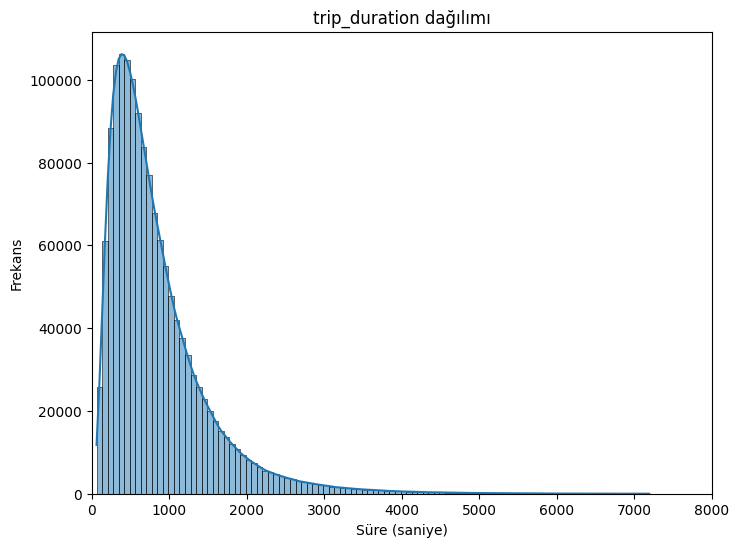

In [ ]:
# trip_duration dağılımını histogram ile inceliyoruz.
plt.figure(figsize=(8,6))
sns.histplot(df['trip_duration'], bins=100, kde=True)
plt.xlim(0, 8000)
plt.title("trip_duration dağılımı")
plt.xlabel("Süre (saniye)")
plt.ylabel("Frekans")
plt.show()


TARGET (y) VE ÖZELLİKLER (X) TANIMLAMA
trip_duration logaritmik forma çevrilerek y değişkeni oluşturulur. Ayrıca vendor_id ve store_and_fwd_flag gibi kategorik sütunlar modellerin sayısal veri gereksinimine uygun hale getirilir (N/Y → 0/1). Ardından sayısal ve kategorik özellikler seçilerek X veri kümesi hazırlanır.

In [ ]:
# X (özellikler) ve y (hedef) değişkenlerini tanımlıyoruz.

# 1) Kategorik sütunları sayısal formata çeviriyoruz
df['vendor_id'] = df['vendor_id'].astype(int)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'N': 0, 'Y': 1}).astype(int)

# 2) Hedef değişken (log-trip_duration)
y = np.log1p(df['trip_duration'])

# 3) Kullanacağımız feature kolonları
feature_cols_numeric = ['distance_km', 'pickup_hour', 'pickup_dayofweek', 'passenger_count']
feature_cols_categorical = ['vendor_id', 'store_and_fwd_flag']

# 4) X matrisini oluştur
X = df[feature_cols_numeric + feature_cols_categorical]

print("X şekli:", X.shape)
print("y şekli:", y.shape)
X.head()


X şekli: (1447628, 6)
y şekli: (1447628,)


,distance_km,pickup_hour,pickup_dayofweek,passenger_count,vendor_id,store_and_fwd_flag
0,1.498521,17,0,1,2,0
1,1.805507,0,6,1,1,0
2,6.385098,11,1,1,2,0
3,1.485498,19,2,1,2,0
4,1.188588,13,5,1,2,0


TRAIN–TEST AYIRMA
Veri seti yüzde 80 eğitim, yüzde 20 test olarak ayrılır. X_train, X_test, y_train, y_test oluşturulur.

In [ ]:
# Veriyi eğitim ve test olarak ayırıyoruz.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Eğitim seti:", X_train.shape)
print("Test seti:", X_test.shape)


Eğitim seti: (1158102, 6)
Test seti: (289526, 6)


DEĞERLENDİRME FONKSİYONU
Tahminleri mantıklı aralıkta kırpar (clip), ardından RMSE, MAE ve R2 gibi metrikleri hem log hem saniye uzayında hesaplar.

In [ ]:
# Tahminleri makul aralıkta kırpıp (clip) sonra metrikleri hesaplıyoruz.

def evaluate_regression(y_true_log, y_pred_log, name="Model"):
    """
    y_true_log ve y_pred_log = log1p(trip_duration) formatında olmalı.
    Tahminleri önce makul aralığa kırpıyoruz, sonra RMSLE, RMSE(sn), MAE(sn), R2 hesaplıyoruz.
    """
    # 1) Tahminleri, gerçek log değerlerinin min / max aralığına kırp (clip)
    lo = y_true_log.min()
    hi = y_true_log.max()
    y_pred_log_clipped = np.clip(y_pred_log, lo, hi)

    # 2) RMSLE (log uzayında)
    mse_log = mean_squared_error(y_true_log, y_pred_log_clipped)
    rmsle = np.sqrt(mse_log)

    # 3) Log'dan saniyeye dön
    y_true_sec = np.expm1(y_true_log)
    y_pred_sec = np.expm1(y_pred_log_clipped)

    # 4) RMSE, MAE, R2
    mse_sec = mean_squared_error(y_true_sec, y_pred_sec)
    rmse = np.sqrt(mse_sec)
    mae = mean_absolute_error(y_true_sec, y_pred_sec)
    r2 = r2_score(y_true_sec, y_pred_sec)

    print(f"{name} Sonuçları:")
    print(f"  RMSLE      : {rmsle:.4f}")
    print(f"  RMSE (sn)  : {rmse:.2f}")
    print(f"  MAE (sn)   : {mae:.2f}")
    print(f"  R2         : {r2:.4f}")


BASELINE MODEL
Her gözlem için aynı tahmini yapan (median değer) basit bir baseline model oluşturulur ve performansı ölçülür. Bu, gerçek modelleri karşılaştırmak için referans sağlar.

In [ ]:
# Herkese aynı süreyi tahmin eden baseline modeli hesaplıyoruz.

baseline_constant = y_train.median()

y_train_pred_baseline = np.full_like(y_train, baseline_constant)
y_test_pred_baseline = np.full_like(y_test, baseline_constant)

print("=== Dumb Baseline - Train ===")
evaluate_regression(y_train, y_train_pred_baseline, name="Dumb Baseline (Train)")

print("\n=== Dumb Baseline - Test ===")
evaluate_regression(y_test, y_test_pred_baseline, name="Dumb Baseline (Test)")


=== Dumb Baseline - Train ===
Dumb Baseline (Train) Sonuçları:
  RMSLE      : 0.7285
  RMSE (sn)  : 677.02
  MAE (sn)   : 442.70
  R2         : -0.0722

=== Dumb Baseline - Test ===
Dumb Baseline (Test) Sonuçları:
  RMSLE      : 0.7269
  RMSE (sn)  : 674.42
  MAE (sn)   : 442.10
  R2         : -0.0736


ÖN İŞLEME PIPELINE’I
Sayısal özellikler StandardScaler ile ölçeklenir, kategorik değişkenler OneHotEncoder ile dönüştürülür. Bu iki işlem ColumnTransformer içinde birleştirilir ve model eğitiminde kullanılacak preprocessing pipeline’ı hazırlanır.

In [ ]:
# sayısal ve kategorik sütunlar için preprocessing pipeline tanımlıyoruz.

numeric_features = feature_cols_numeric
categorical_features = feature_cols_categorical

numeric_transformer = Pipeline([("scaler", StandardScaler())])
categorical_transformer = Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['distance_km', 'pickup_hour',
                                  'pickup_dayofweek', 'passenger_count']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['vendor_id', 'store_and_fwd_flag'])])

Linear Regression pipeline’ının eğitilmesi

Bu hücrede yine preprocessing + Linear Regression pipeline’ı kurulup eğitilir. Model başarılı şekilde train set üzerinde fit edilir.

In [ ]:
# Preprocessing + LinearRegression pipeline'ını eğitiyoruz.

linreg_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

linreg_model.fit(X_train, y_train)
print("Linear Regression modeli eğitildi.")


Linear Regression modeli eğitildi.


Linear Regression model performansının ölçülmesi

Eğitilen Linear Regression modeli ile hem train hem test üzerinde tahmin yapılır. Ardından RMSE, MAE ve R2 gibi metrikler hesaplanarak model performansı raporlanır.

In [ ]:
# Linear Regression modelinin performansını ölçüyoruz.

y_train_pred_lin = linreg_model.predict(X_train)
y_test_pred_lin = linreg_model.predict(X_test)

print("=== Linear Regression - Train ===")
evaluate_regression(y_train, y_train_pred_lin, name="Linear Regression (Train)")

print("\n=== Linear Regression - Test ===")
evaluate_regression(y_test, y_test_pred_lin, name="Linear Regression (Test)")


=== Linear Regression - Train ===
Linear Regression (Train) Sonuçları:
  RMSLE      : 0.5430
  RMSE (sn)  : 561.66
  MAE (sn)   : 340.30
  R2         : 0.2620

=== Linear Regression - Test ===
Linear Regression (Test) Sonuçları:
  RMSLE      : 0.5419
  RMSE (sn)  : 560.45
  MAE (sn)   : 340.22
  R2         : 0.2586


Bu hücrede preprocessing pipeline ve Ridge Regression modeli birleştirilerek eğitilir. Eğitim ve test verileri üzerinde tahminler yapılır ve performans metrikleri hesaplanarak model değerlendirilir.

In [ ]:
# Ridge Regression modelini eğitip test ediyoruz.

ridge_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

ridge_model.fit(X_train, y_train)

y_train_pred_ridge = ridge_model.predict(X_train)
y_test_pred_ridge = ridge_model.predict(X_test)

print("=== Ridge Regression - Train ===")
evaluate_regression(y_train, y_train_pred_ridge, name="Ridge Regression (Train)")

print("\n=== Ridge Regression - Test ===")
evaluate_regression(y_test, y_test_pred_ridge, name="Ridge Regression (Test)")


=== Ridge Regression - Train ===
Ridge Regression (Train) Sonuçları:
  RMSLE      : 0.5430
  RMSE (sn)  : 561.66
  MAE (sn)   : 340.30
  R2         : 0.2620

=== Ridge Regression - Test ===
Ridge Regression (Test) Sonuçları:
  RMSLE      : 0.5419
  RMSE (sn)  : 560.45
  MAE (sn)   : 340.22
  R2         : 0.2586


Sonuç tablosu oluşturma (Baseline, Linear, Ridge) Bu hücrede tüm modeller için aynı clipping + değerlendirme mantığı kullanılır. add_result fonksiyonu ile RMSE, RMSLE, MAE ve R2 değerleri listeye eklenir. Sonuçlar bir DataFrame’e dönüştürülerek tüm modeller tek tabloda karşılaştırılır.

In [ ]:
# Sonuç tablosu için aynı clipping mantığını kullanıyoruz.

results = []

def add_result(name, y_true_log, y_pred_log):
    lo = y_true_log.min()
    hi = y_true_log.max()
    y_pred_log_clipped = np.clip(y_pred_log, lo, hi)

    mse_log = mean_squared_error(y_true_log, y_pred_log_clipped)
    rmsle = np.sqrt(mse_log)

    y_true_sec = np.expm1(y_true_log)
    y_pred_sec = np.expm1(y_pred_log_clipped)

    rmse = np.sqrt(mean_squared_error(y_true_sec, y_pred_sec))
    mae = mean_absolute_error(y_true_sec, y_pred_sec)
    r2 = r2_score(y_true_sec, y_pred_sec)

    results.append([name, rmsle, rmse, mae, r2])

add_result("Dumb Baseline", y_test, y_test_pred_baseline)
add_result("Linear Regression", y_test, y_test_pred_lin)
add_result("Ridge Regression", y_test, y_test_pred_ridge)

results_df = pd.DataFrame(results, columns=["Model","RMSLE","RMSE(sn)","MAE(sn)","R2"])
results_df


,Model,RMSLE,RMSE(sn),MAE(sn),R2
0,Dumb Baseline,0.726865,674.420628,442.104540,-0.073591
1,Linear Regression,0.541888,560.453396,340.224599,0.258594
2,Ridge Regression,0.541888,560.452812,340.224470,0.258596


SelectKBest ile en iyi 3 sayısal özelliğin seçilmesi
Bu hücrede yalnızca sayısal sütunlar seçilir ve f_regression skoru kullanılarak en iyi 3 özellik belirlenir. Bu üç özellik ile yeni X_fs veri seti oluşturulur. Ardından train/test ayrımı bu yeni özellik seti için tekrar yapılır.

In [ ]:
# SelectKBest Feature Selection 3 feature için

from sklearn.feature_selection import SelectKBest, f_regression

# 1) Sayısal sütunları seçiyoruz
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X_num = X[numeric_cols]

print("Sayısal sütunlar:", list(numeric_cols))

# 2) En iyi 3 sayısal özelliği seçelim
k = 3
selector = SelectKBest(score_func=f_regression, k=k)
X_fs_num = selector.fit_transform(X_num, y)

selected_indices = selector.get_support(indices=True)
selected_features = [numeric_cols[i] for i in selected_indices]

print(f"\nSelectKBest ile seçilen {k} feature:")
for f in selected_features:
    print("-", f)

# 3) Seçilen feature'larla yeni X_fs DataFrame'i
X_fs = pd.DataFrame(X_fs_num, columns=selected_features)

# 4) FS sonrası train/test ayırma
from sklearn.model_selection import train_test_split

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y, test_size=0.2, random_state=42
)

print("\nFS sonrası X_train şekli:", X_train_fs.shape)
print("FS sonrası X_test şekli :", X_test_fs.shape)


Sayısal sütunlar: ['distance_km', 'passenger_count', 'vendor_id', 'store_and_fwd_flag']

SelectKBest ile seçilen 3 feature:
- distance_km
- passenger_count
- store_and_fwd_flag

FS sonrası X_train şekli: (1158102, 3)
FS sonrası X_test şekli : (289526, 3)


Feature Selection sonrası Linear ve Ridge modelleri
Seçilen 3 özellik kullanılarak Linear Regression ve Ridge Regression modelleri yeniden eğitilir. Test seti performansları (RMSE, MAE, R2) ölçülür. Sonuçlar Feature Selection’ın etkisini göstermek için raporlanır.

In [ ]:
# Feature Selection Sonrası Linear ve Ridge

from sklearn.linear_model import LinearRegression, Ridge

# 1) Linear Regression + SelectKBest
lin_fs = LinearRegression()
lin_fs.fit(X_train_fs, y_train_fs)
y_test_pred_lin_fs = lin_fs.predict(X_test_fs)

print("=== Linear + SelectKBest (Test) ===")
evaluate_regression(y_test_fs, y_test_pred_lin_fs, name="Linear + FS")

# 2) Ridge Regression + SelectKBest
ridge_fs = Ridge(alpha=1.0)
ridge_fs.fit(X_train_fs, y_train_fs)
y_test_pred_ridge_fs = ridge_fs.predict(X_test_fs)

print("\n=== Ridge + SelectKBest (Test) ===")
evaluate_regression(y_test_fs, y_test_pred_ridge_fs, name="Ridge + FS")


=== Linear + SelectKBest (Test) ===
Linear + FS Sonuçları:
  RMSLE      : 0.5437
  RMSE (sn)  : 560.22
  MAE (sn)   : 341.03
  R2         : 0.2592

=== Ridge + SelectKBest (Test) ===
Ridge + FS Sonuçları:
  RMSLE      : 0.5437
  RMSE (sn)  : 560.22
  MAE (sn)   : 341.03
  R2         : 0.2592


PCA ile boyut indirgeme (95% varyans)
Sayısal sütunlar seçilir, StandardScaler ile ölçeklenir ve PCA uygulanarak toplam varyansın %95’ini açıklayan bileşen sayısı otomatik belirlenir. PCA sonrası oluşan yeni bileşen matrisi için train/test ayrımı gerçekleştirilir.

In [ ]:
# PCA Dimension Reduction

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Yine sayısal sütunlar üzerinden PCA yapalım
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X_num = X[numeric_cols]

# 2) StandardScaler ile ölçekleme
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# 3) PCA ile %95 varyansı açıklayan bileşenler
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_num_scaled)

print("PCA ile elde edilen bileşen sayısı:", pca.n_components_)

# 4) PCA sonrası train/test ayrımı
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

print("PCA sonrası X_train şekli:", X_train_pca.shape)
print("PCA sonrası X_test şekli :", X_test_pca.shape)


PCA ile elde edilen bileşen sayısı: 4
PCA sonrası X_train şekli: (1158102, 4)
PCA sonrası X_test şekli : (289526, 4)


PCA sonrası Linear ve Ridge modelleri
PCA ile indirgenmiş veri üzerinde Linear Regression ve Ridge Regression modelleri eğitilir. Test performansları hesaplanarak PCA’nın model başarısına etkisi değerlendirilir.

In [ ]:
# PCA Sonrası Linear ve Ridge

# 1) Linear Regression + PCA
lin_pca = LinearRegression()
lin_pca.fit(X_train_pca, y_train_pca)
y_test_pred_lin_pca = lin_pca.predict(X_test_pca)

print("=== Linear + PCA (Test) ===")
evaluate_regression(y_test_pca, y_test_pred_lin_pca, name="Linear + PCA")

# 2) Ridge Regression + PCA
ridge_pca = Ridge(alpha=1.0)
ridge_pca.fit(X_train_pca, y_train_pca)
y_test_pred_ridge_pca = ridge_pca.predict(X_test_pca)

print("\n=== Ridge + PCA (Test) ===")
evaluate_regression(y_test_pca, y_test_pred_ridge_pca, name="Ridge + PCA")


=== Linear + PCA (Test) ===
Linear + PCA Sonuçları:
  RMSLE      : 0.5437
  RMSE (sn)  : 560.23
  MAE (sn)   : 341.03
  R2         : 0.2592

=== Ridge + PCA (Test) ===
Ridge + PCA Sonuçları:
  RMSLE      : 0.5437
  RMSE (sn)  : 560.23
  MAE (sn)   : 341.03
  R2         : 0.2592


Tüm modellerin özet sonuç tablosu

Bu hücrede üç model grubu özetlenir:

Orijinal özelliklerle Linear & Ridge

Feature Selection sonrası Linear & Ridge

PCA sonrası Linear & Ridge

Her birinin hangi özellik setini kullandığı "Not" sütununa yazılır ve sonuçlar tek tabloda birleştirilir.

In [ ]:
#  Tüm Base Modellerin Sonuç Özeti

summary_rows = []

# 1) Orijinal Linear & Ridge (burada y_test_pred_lin / y_test_pred_ridge senin eski modellerinden geliyor)
summary_rows.append(["Linear (Original)", "Orijinal feature set"])
summary_rows.append(["Ridge (Original)",  "Orijinal feature set"])

# 2) FS sonrası Linear & Ridge
summary_rows.append(["Linear + SelectKBest", "3 feature (SelectKBest)"])
summary_rows.append(["Ridge + SelectKBest",  "3 feature (SelectKBest)"])


# 3) PCA sonrası Linear & Ridge
summary_rows.append(["Linear + PCA",  "PCA bileşenleri (95% var.)"])
summary_rows.append(["Ridge + PCA",   "PCA bileşenleri (95% var.)"])

results_models = [row[0] for row in summary_rows]
results_notes  = [row[1] for row in summary_rows]


results_df_k2 = pd.DataFrame({
    "Model": results_models,
    "Not": results_notes
})

results_df_k2


,Model,Not
0,Linear (Original),Orijinal feature set
1,Ridge (Original),Orijinal feature set
2,Linear + SelectKBest,3 feature (SelectKBest)
3,Ridge + SelectKBest,3 feature (SelectKBest)
4,Linear + PCA,PCA bileşenleri (95% var.)
5,Ridge + PCA,PCA bileşenleri (95% var.)


Bu hücrede final aşaması için gerekli kütüphaneleri tekrar yüklüyorum


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, r2_score


Bu hücrede log-transform uygulanarak hedef değişken hazırlanır ve veri train/test olarak bölünür.

In [ ]:
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((1158102, 6), (289526, 6))

Bu hücre SelectKBest ile veri setinin en anlamlı 3 sayısal özelliğini seçer.

In [ ]:
numeric_cols = X.select_dtypes(include=['float64','int64']).columns
X_num = X[numeric_cols]

selector = SelectKBest(score_func=f_regression, k=3)
X_fs_num = selector.fit_transform(X_num, y_log)

selected_indices = selector.get_support(indices=True)
selected_features = [numeric_cols[i] for i in selected_indices]

print("Seçilen 3 feature:", selected_features)


Seçilen 3 feature: ['distance_km', 'passenger_count', 'store_and_fwd_flag']


Bu adımda PCA ile boyut indirgeme yapılır.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("PCA bileşen sayısı:", pca.n_components_)


PCA bileşen sayısı: 4


Bu model tuning gerektirmeyen baseline geliştirilmiş modeldir

In [ ]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

pred_lin = linreg.predict(X_test)
rmsle_lin = mean_squared_log_error(y_test, pred_lin) ** 0.5

print("Linear Regression RMSLE:", rmsle_lin)


Linear Regression RMSLE: 0.02586482550637988


Bu hücrede Ridge Regression modeli için farklı alpha değerleri deniyorum. GridSearchCV ile 5-fold cross-validation kullanarak en iyi alpha değerini ve CV RMSLE skorunu buluyorum.

In [ ]:
# Ridge Regression + GridSearchCV (final tuning)

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 5, 10, 20, 50, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    scoring='neg_mean_squared_log_error',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("En iyi alpha:", grid.best_params_)
print("En iyi RMSLE (CV):", (-grid.best_score_)**0.5)


En iyi alpha: {'ridge__alpha': 0.001}
En iyi RMSLE (CV): 0.025948366098516792


Bu hücrede GridSearchCV sonucu bulunan en iyi Ridge modelini kullanarak test setinde RMSLE, MAE ve R² performanslarını hesaplıyoruz

In [ ]:
# En iyi modeli alıyoruz
best_ridge = grid.best_estimator_

# Test tahminleri
y_pred_test = best_ridge.predict(X_test)

# Performans metrikleri
rmsle_test = mean_squared_log_error(y_test, y_pred_test) ** 0.5
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("Final Ridge Test RMSLE:", rmsle_test)
print("Final Ridge Test MAE:", mae_test)
print("Final Ridge Test R2:", r2_test)


Final Ridge Test RMSLE: 0.025864825507663548
Final Ridge Test MAE: 0.05941164164982984
Final Ridge Test R2: 0.38072240274139035


Bu adımda Linear Regression ve en iyi Ridge modelinin performanslarını tek tabloda karşılaştırıyoruz.

In [ ]:
results_k2 = pd.DataFrame([
    ["Linear Regression", rmsle_lin, None, None],
    ["Ridge Regression (Best)", rmsle_test, mae_test, r2_test]
], columns=["Model", "RMSLE", "MAE", "R2"])

results_k2


,Model,RMSLE,MAE,R2
0,Linear Regression,0.025865,NaN,NaN
1,Ridge Regression (Best),0.025865,0.059412,0.380722


Bu adımda Ridge tahminlerini ve gerçek değerleri grafik üzerinde gösteriyoruz.

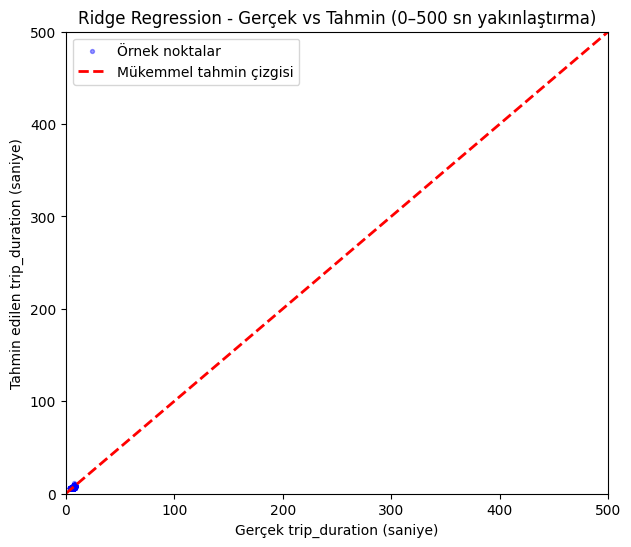

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Log uzayından gerçek saniyelere dönüş
y_test_sec = np.expm1(np.maximum(y_test.to_numpy(), 0))
y_pred_sec = np.expm1(np.maximum(y_pred_test, 0))

# 2) Test setinden rastgele 10.000 örnek seçelim
n_samples = 10000
idx = np.random.choice(len(y_test_sec), size=n_samples, replace=False)

# 3) Seçilen örnekleri alıyoruz (NumPy olduğu için direkt indeksleme)
y_test_sample = y_test_sec[idx]
y_pred_sample = y_pred_sec[idx]

# 4) Scatter grafiği
plt.figure(figsize=(7,6))
plt.scatter(y_test_sample, y_pred_sample, alpha=0.4, s=8, color="blue", label="Örnek noktalar")
plt.plot([0, 500], [0, 500], 'r--', linewidth=2, label="Mükemmel tahmin çizgisi")
çç
plt.xlim(0, 500)
plt.ylim(0, 500)

plt.xlabel("Gerçek trip_duration (saniye)")
plt.ylabel("Tahmin edilen trip_duration (saniye)")
plt.title("Ridge Regression - Gerçek vs Tahmin (0–500 sn yakınlaştırma)")
plt.legend()
plt.show()

